# USA–Iran–India Geopolitical Forecasting System

## Multi-Agent Strategic Simulation Using:
- Historical Geopolitical Events
- Real Financial Market Data
- Markov Chains
- Monte Carlo Simulation
- Probabilistic Game Theory

INSTALL REQUIRED PACKAGES

In [1]:
# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

!pip install yfinance --quiet

IMPORT LIBRARIES

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Define market tickers

In [3]:
# ============================================================
# MARKET TICKERS
# ============================================================

tickers = {

    "Brent_Oil": "BZ=F",
    "SP500": "^GSPC",
    "NIFTY50": "^NSEI",
    "Gold": "GC=F",
    "VIX": "^VIX"
}

Download historical market data (1980–Present)

In [4]:
# ============================================================
# DOWNLOAD HISTORICAL MARKET DATA
# ============================================================

market_data = {}

for name, ticker in tickers.items():

    data = yf.download(
        ticker,
        start="1980-01-01",
        end="2025-01-01"
    )

    market_data[name] = data

    print(f"{name} downloaded successfully")

/tmp/ipykernel_3582/465248969.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3582/465248969.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


Brent_Oil downloaded successfully


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3582/465248969.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3582/465248969.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


SP500 downloaded successfully
NIFTY50 downloaded successfully


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3582/465248969.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


Gold downloaded successfully


[*********************100%***********************]  1 of 1 completed

VIX downloaded successfully


CHECK SAMPLE DATA

In [5]:
# ============================================================
# CHECK SAMPLE DATA
# ============================================================

market_data["Brent_Oil"].head()

Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2007-07-30,75.739998,76.529999,75.440002,75.849998,2575
2007-07-31,77.050003,77.169998,75.669998,75.699997,3513
2007-08-01,75.349998,77.059998,74.860001,77.000000,3930
2007-08-02,75.760002,76.209999,74.269997,75.220001,6180
2007-08-03,74.750000,76.000000,74.529999,75.389999,4387


Create geopolitical events dataset

In [6]:
# ============================================================
# USA–IRAN–INDIA GEOPOLITICAL EVENTS
# ============================================================

events = [

    {
        "date": "1979-11-04",
        "usa_action": "Economic Sanctions",
        "iran_action": "Hostage Crisis",
        "india_response": "Neutral Diplomacy",
        "severity": 9,
        "category": "Diplomatic Crisis"
    },

    {
        "date": "1980-09-22",
        "usa_action": "Support Allies",
        "iran_action": "War Mobilization",
        "india_response": "Trade Balancing",
        "severity": 10,
        "category": "War"
    },

    {
        "date": "1988-07-03",
        "usa_action": "Military Action",
        "iran_action": "Regional Escalation",
        "india_response": "Strategic Neutrality",
        "severity": 8,
        "category": "Military Incident"
    },

    {
        "date": "2002-08-14",
        "usa_action": "Diplomatic Pressure",
        "iran_action": "Nuclear Expansion",
        "india_response": "Energy Balancing",
        "severity": 8,
        "category": "Nuclear"
    },

    {
        "date": "2015-07-14",
        "usa_action": "Diplomatic Agreement",
        "iran_action": "Nuclear Compliance",
        "india_response": "Energy Cooperation",
        "severity": 4,
        "category": "Diplomatic Agreement"
    },

    {
        "date": "2018-05-08",
        "usa_action": "JCPOA Withdrawal",
        "iran_action": "Nuclear Expansion",
        "india_response": "Oil Diversification",
        "severity": 8,
        "category": "Sanctions"
    },

    {
        "date": "2020-01-03",
        "usa_action": "Soleimani Strike",
        "iran_action": "Missile Retaliation",
        "india_response": "Strategic Neutrality",
        "severity": 10,
        "category": "Military Strike"
    },

    {
        "date": "2024-04-13",
        "usa_action": "Regional Support",
        "iran_action": "Drone and Missile Attack",
        "india_response": "Energy Security Measures",
        "severity": 9,
        "category": "Direct Conflict"
    }
]

Convert to DataFrame

In [7]:
# ============================================================
# EVENTS DATAFRAME
# ============================================================

events_df = pd.DataFrame(events)

events_df["date"] = pd.to_datetime(events_df["date"])

events_df

,date,usa_action,iran_action,india_response,severity,category
0,1979-11-04,Economic Sanctions,Hostage Crisis,Neutral Diplomacy,9,Diplomatic Crisis
1,1980-09-22,Support Allies,War Mobilization,Trade Balancing,10,War
2,1988-07-03,Military Action,Regional Escalation,Strategic Neutrality,8,Military Incident
3,2002-08-14,Diplomatic Pressure,Nuclear Expansion,Energy Balancing,8,Nuclear
4,2015-07-14,Diplomatic Agreement,Nuclear Compliance,Energy Cooperation,4,Diplomatic Agreement
5,2018-05-08,JCPOA Withdrawal,Nuclear Expansion,Oil Diversification,8,Sanctions
6,2020-01-03,Soleimani Strike,Missile Retaliation,Strategic Neutrality,10,Military Strike
7,2024-04-13,Regional Support,Drone and Missile Attack,Energy Security Measures,9,Direct Conflict


Calculate market returns

In [8]:
# ============================================================
# CALCULATE DAILY RETURNS
# ============================================================

returns_data = {}

for name, data in market_data.items():

    df = data.copy()

    df["Returns"] = df["Close"].pct_change()

    returns_data[name] = df

EVENT IMPACT ANALYSIS FUNCTION

In [9]:
# ============================================================
# EVENT IMPACT ANALYSIS FUNCTION
# ============================================================

def analyze_event_impact(
    event_date,
    market_df,
    window_before=10,
    window_after=10
):

    event_date = pd.to_datetime(event_date)

    data = market_df.copy()

    data = data.reset_index()

    event_index = data[data["Date"] >= event_date].index[0]

    start_index = max(0, event_index - window_before)
    end_index = min(len(data) - 1, event_index + window_after)

    window_data = data.iloc[start_index:end_index + 1].copy()

    return window_data

Test on oil prices

In [10]:
# ============================================================
# TEST EVENT IMPACT
# ============================================================

soleimani_oil = analyze_event_impact(
    "2020-01-03",
    market_data["Brent_Oil"]
)

soleimani_oil.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
3065,2019-12-18,66.169998,66.419998,65.570000,65.830002,31943
3066,2019-12-19,66.540001,66.779999,66.040001,66.120003,29280
3067,2019-12-20,66.139999,66.709999,65.730003,66.519997,33986
3068,2019-12-23,66.389999,66.599998,65.809998,66.209999,21599
3069,2019-12-24,67.199997,67.250000,66.370003,66.510002,18562


Visualize oil reaction

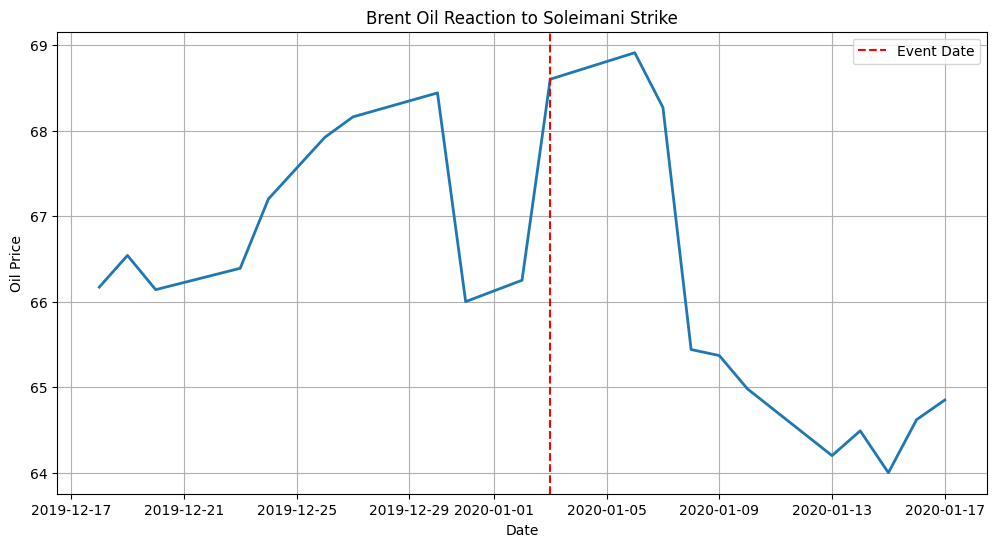

In [11]:
# ============================================================
# VISUALIZE OIL REACTION
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    soleimani_oil["Date"],
    soleimani_oil["Close"],
    linewidth=2
)

plt.axvline(
    pd.to_datetime("2020-01-03"),
    color="red",
    linestyle="--",
    label="Event Date"
)

plt.title("Brent Oil Reaction to Soleimani Strike")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True)

plt.show()

MULTI-MARKET EVENT ANALYSIS

In [12]:
# ============================================================
# MULTI-MARKET EVENT ANALYSIS
# ============================================================

def compare_markets_for_event(
    event_date,
    market_data,
    markets,
    title
):

    plt.figure(figsize=(14,7))

    for market in markets:

        data = analyze_event_impact(
            event_date,
            market_data[market]
        )

        normalized = (
            data["Close"] / data["Close"].iloc[0]
        ) * 100

        plt.plot(
            data["Date"],
            normalized,
            label=market
        )

    plt.axvline(
        pd.to_datetime(event_date),
        color="red",
        linestyle="--",
        label="Event"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Normalized Index")
    plt.legend()
    plt.grid(True)

    plt.show()

Compare all markets

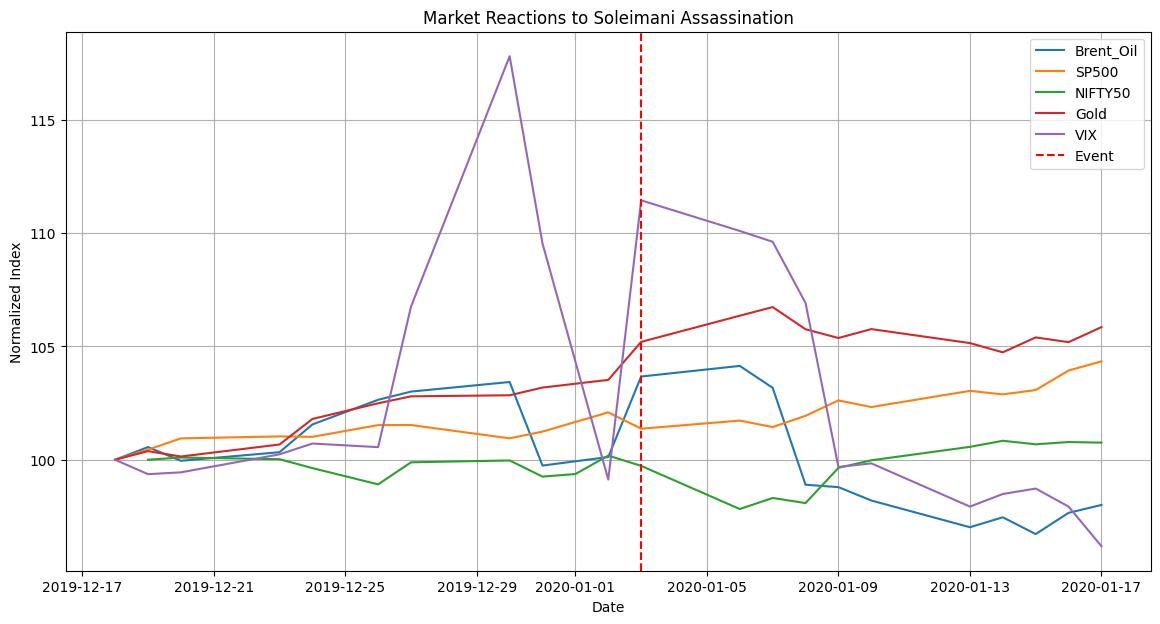

In [13]:
# ============================================================
# COMPARE MARKET REACTIONS
# ============================================================

compare_markets_for_event(

    event_date="2020-01-03",

    market_data=market_data,

    markets=[
        "Brent_Oil",
        "SP500",
        "NIFTY50",
        "Gold",
        "VIX"
    ],

    title="Market Reactions to Soleimani Assassination"
)

GEOPOLITICAL STATES

In [14]:
# ============================================================
# GEOPOLITICAL STATES
# ============================================================

state_mapping = {

    0: "Stable",
    1: "Moderate Tension",
    2: "High Tension",
    3: "Crisis"
}

Convert severity into states

In [15]:
# ============================================================
# CONVERT SEVERITY TO STATES
# ============================================================

def severity_to_state(severity):

    if severity <= 3:
        return 0

    elif severity <= 6:
        return 1

    elif severity <= 8:
        return 2

    else:
        return 3

Apply state classification

In [16]:
# ============================================================
# APPLY STATES TO EVENTS
# ============================================================

events_df["state"] = events_df["severity"].apply(
    severity_to_state
)

events_df["state_name"] = events_df["state"].map(
    state_mapping
)

events_df

,date,usa_action,iran_action,india_response,severity,category,state,state_name
0,1979-11-04,Economic Sanctions,Hostage Crisis,Neutral Diplomacy,9,Diplomatic Crisis,3,Crisis
1,1980-09-22,Support Allies,War Mobilization,Trade Balancing,10,War,3,Crisis
2,1988-07-03,Military Action,Regional Escalation,Strategic Neutrality,8,Military Incident,2,High Tension
3,2002-08-14,Diplomatic Pressure,Nuclear Expansion,Energy Balancing,8,Nuclear,2,High Tension
4,2015-07-14,Diplomatic Agreement,Nuclear Compliance,Energy Cooperation,4,Diplomatic Agreement,1,Moderate Tension
5,2018-05-08,JCPOA Withdrawal,Nuclear Expansion,Oil Diversification,8,Sanctions,2,High Tension
6,2020-01-03,Soleimani Strike,Missile Retaliation,Strategic Neutrality,10,Military Strike,3,Crisis
7,2024-04-13,Regional Support,Drone and Missile Attack,Energy Security Measures,9,Direct Conflict,3,Crisis


BUILD STATE TRANSITIONS

In [17]:
# ============================================================
# BUILD STATE TRANSITIONS
# ============================================================

transitions = []

states = events_df["state"].tolist()

for i in range(len(states) - 1):

    current_state = states[i]
    next_state = states[i + 1]

    transitions.append(
        (current_state, next_state)
    )

transitions

[(3, 3), (3, 2), (2, 2), (2, 1), (1, 2), (2, 3), (3, 3)]

TRANSITION MATRIX

In [18]:
# ============================================================
# TRANSITION MATRIX
# ============================================================

transition_matrix = np.zeros((4,4))

for current_state, next_state in transitions:

    transition_matrix[current_state][next_state] += 1

for i in range(len(transition_matrix)):

    row_sum = transition_matrix[i].sum()

    if row_sum > 0:
        transition_matrix[i] = (
            transition_matrix[i] / row_sum
        )

transition_matrix

array([[0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        ],
       [0.        , 0.33333333, 0.33333333, 0.33333333],
       [0.        , 0.        , 0.33333333, 0.66666667]])

Visualize transition matrix

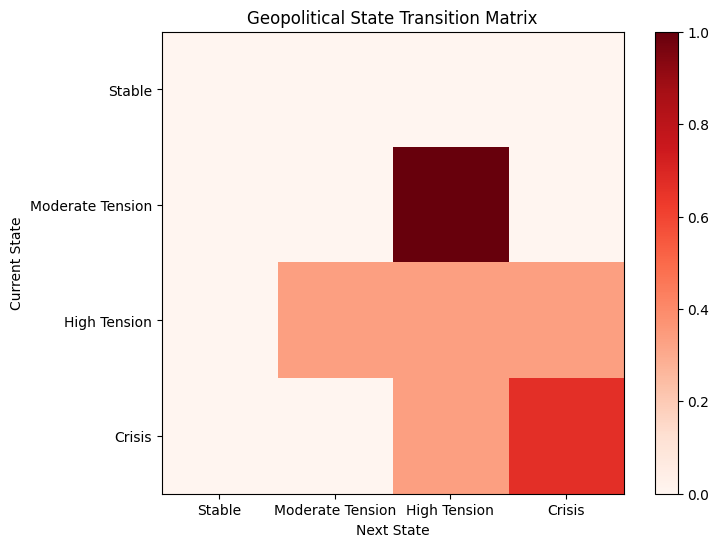

In [19]:
# ============================================================
# VISUALIZE TRANSITION MATRIX
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(
    transition_matrix,
    cmap="Reds"
)

plt.colorbar()

plt.xticks(
    range(4),
    [state_mapping[i] for i in range(4)]
)

plt.yticks(
    range(4),
    [state_mapping[i] for i in range(4)]
)

plt.xlabel("Next State")
plt.ylabel("Current State")

plt.title("Geopolitical State Transition Matrix")

plt.show()

 STRATEGIC ACTION SPACES

In [20]:
# ============================================================
# STRATEGIC ACTION SPACES
# ============================================================

usa_actions = [
    "Diplomatic Negotiation",
    "Economic Sanctions",
    "Military Pressure",
    "Naval Deployment",
    "Cyber Operations"
]

iran_actions = [
    "Diplomatic Response",
    "Proxy Escalation",
    "Missile Demonstration",
    "Oil Route Threat",
    "Nuclear Expansion"
]

india_actions = [
    "Neutral Diplomacy",
    "Oil Diversification",
    "Strategic Mediation",
    "Trade Balancing",
    "Energy Security Measures"
]

Define state-based action probabilities

In [21]:
# ============================================================
# STATE-BASED STRATEGIC PROBABILITIES
# ============================================================

state_action_probabilities = {

    0: {  # Stable

        "USA": {
            "Diplomatic Negotiation": 0.50,
            "Economic Sanctions": 0.20,
            "Military Pressure": 0.05,
            "Naval Deployment": 0.10,
            "Cyber Operations": 0.15
        },

        "Iran": {
            "Diplomatic Response": 0.55,
            "Proxy Escalation": 0.10,
            "Missile Demonstration": 0.05,
            "Oil Route Threat": 0.05,
            "Nuclear Expansion": 0.25
        },

        "India": {
            "Neutral Diplomacy": 0.40,
            "Oil Diversification": 0.20,
            "Strategic Mediation": 0.25,
            "Trade Balancing": 0.10,
            "Energy Security Measures": 0.05
        }
    },

    1: {  # Moderate Tension

        "USA": {
            "Diplomatic Negotiation": 0.25,
            "Economic Sanctions": 0.35,
            "Military Pressure": 0.15,
            "Naval Deployment": 0.15,
            "Cyber Operations": 0.10
        },

        "Iran": {
            "Diplomatic Response": 0.20,
            "Proxy Escalation": 0.30,
            "Missile Demonstration": 0.15,
            "Oil Route Threat": 0.10,
            "Nuclear Expansion": 0.25
        },

        "India": {
            "Neutral Diplomacy": 0.35,
            "Oil Diversification": 0.25,
            "Strategic Mediation": 0.20,
            "Trade Balancing": 0.10,
            "Energy Security Measures": 0.10
        }
    },

    2: {  # High Tension

        "USA": {
            "Diplomatic Negotiation": 0.10,
            "Economic Sanctions": 0.35,
            "Military Pressure": 0.25,
            "Naval Deployment": 0.20,
            "Cyber Operations": 0.10
        },

        "Iran": {
            "Diplomatic Response": 0.10,
            "Proxy Escalation": 0.35,
            "Missile Demonstration": 0.25,
            "Oil Route Threat": 0.15,
            "Nuclear Expansion": 0.15
        },

        "India": {
            "Neutral Diplomacy": 0.30,
            "Oil Diversification": 0.30,
            "Strategic Mediation": 0.15,
            "Trade Balancing": 0.10,
            "Energy Security Measures": 0.15
        }
    },

    3: {  # Crisis

        "USA": {
            "Diplomatic Negotiation": 0.05,
            "Economic Sanctions": 0.20,
            "Military Pressure": 0.35,
            "Naval Deployment": 0.25,
            "Cyber Operations": 0.15
        },

        "Iran": {
            "Diplomatic Response": 0.05,
            "Proxy Escalation": 0.35,
            "Missile Demonstration": 0.30,
            "Oil Route Threat": 0.20,
            "Nuclear Expansion": 0.10
        },

        "India": {
            "Neutral Diplomacy": 0.20,
            "Oil Diversification": 0.35,
            "Strategic Mediation": 0.10,
            "Trade Balancing": 0.10,
            "Energy Security Measures": 0.25
        }
    }
}

ACTION PREDICTION FUNCTION

In [22]:
# ============================================================
# ACTION PREDICTION FUNCTION
# ============================================================

def predict_actions(current_state):

    predictions = {}

    for country in ["USA", "Iran", "India"]:

        actions = list(
            state_action_probabilities[current_state][country].keys()
        )

        probabilities = list(
            state_action_probabilities[current_state][country].values()
        )

        chosen_action = np.random.choice(
            actions,
            p=probabilities
        )

        predictions[country] = chosen_action

    return predictions

Test action prediction

In [23]:
# ============================================================
# TEST ACTION PREDICTION
# ============================================================

current_state = 3

predictions = predict_actions(current_state)

print("Current State:", state_mapping[current_state])

print("\nPredicted Strategic Actions:\n")

for country, action in predictions.items():

    print(country, "→", action)

Current State: Crisis

Predicted Strategic Actions:

USA → Military Pressure
Iran → Proxy Escalation
India → Oil Diversification


NEXT STATE PREDICTION

In [24]:
# ============================================================
# NEXT STATE PREDICTION
# ============================================================

def predict_next_state(current_state):

    probabilities = transition_matrix[current_state]

    next_state = np.random.choice(
        [0,1,2,3],
        p=probabilities
    )

    return next_state

MARKET IMPACT ASSUMPTIONS

In [25]:
# ============================================================
# MARKET IMPACT ASSUMPTIONS
# ============================================================

market_impacts = {

    0: {  # Stable
        "oil": 0.2,
        "sp500": 0.5,
        "nifty": 0.5,
        "gold": -0.2,
        "vix": -0.3
    },

    1: {  # Moderate Tension
        "oil": 1.0,
        "sp500": -0.5,
        "nifty": -0.8,
        "gold": 0.7,
        "vix": 1.0
    },

    2: {  # High Tension
        "oil": 3.0,
        "sp500": -2.0,
        "nifty": -2.5,
        "gold": 2.0,
        "vix": 4.0
    },

    3: {  # Crisis
        "oil": 6.0,
        "sp500": -5.0,
        "nifty": -6.0,
        "gold": 4.0,
        "vix": 8.0
    }
}

FUTURE SCENARIO SIMULATION ENGINE

In [26]:
# ============================================================
# FUTURE SCENARIO SIMULATION ENGINE
# ============================================================

def simulate_future(
    start_state,
    steps=20
):

    simulation_results = []

    current_state = start_state

    for step in range(steps):

        predicted_actions = predict_actions(current_state)

        impacts = market_impacts[current_state]

        simulation_results.append({

            "step": step,

            "state": state_mapping[current_state],

            "USA_action": predicted_actions["USA"],

            "Iran_action": predicted_actions["Iran"],

            "India_action": predicted_actions["India"],

            "Oil_Impact_%": impacts["oil"],

            "SP500_Impact_%": impacts["sp500"],

            "NIFTY50_Impact_%": impacts["nifty"],

            "Gold_Impact_%": impacts["gold"],

            "VIX_Impact_%": impacts["vix"]
        })

        current_state = predict_next_state(current_state)

    return pd.DataFrame(simulation_results)

RUN FUTURE SIMULATION

In [27]:
# ============================================================
# RUN FUTURE SIMULATION
# ============================================================

future_simulation = simulate_future(
    start_state=2,
    steps=20
)

future_simulation

,step,state,USA_action,Iran_action,India_action,Oil_Impact_%,SP500_Impact_%,NIFTY50_Impact_%,Gold_Impact_%,VIX_Impact_%
0,0,High Tension,Economic Sanctions,Oil Route Threat,Oil Diversification,3.0,-2.0,-2.5,2.0,4.0
1,1,Crisis,Cyber Operations,Proxy Escalation,Energy Security Measures,6.0,-5.0,-6.0,4.0,8.0
2,2,Crisis,Naval Deployment,Proxy Escalation,Trade Balancing,6.0,-5.0,-6.0,4.0,8.0
3,3,High Tension,Naval Deployment,Proxy Escalation,Oil Diversification,3.0,-2.0,-2.5,2.0,4.0
4,4,Crisis,Cyber Operations,Nuclear Expansion,Energy Security Measures,6.0,-5.0,-6.0,4.0,8.0
5,5,Crisis,Economic Sanctions,Diplomatic Response,Energy Security Measures,6.0,-5.0,-6.0,4.0,8.0
6,6,High Tension,Military Pressure,Oil Route Threat,Neutral Diplomacy,3.0,-2.0,-2.5,2.0,4.0
7,7,High Tension,Diplomatic Negotiation,Proxy Escalation,Strategic Mediation,3.0,-2.0,-2.5,2.0,4.0
8,8,Moderate Tension,Economic Sanctions,Diplomatic Response,Oil Diversification,1.0,-0.5,-0.8,0.7,1.0
9,9,High Tension,Economic Sanctions,Diplomatic Response,Oil Diversification,3.0,-2.0,-2.5,2.0,4.0


VISUALIZE STATE EVOLUTION

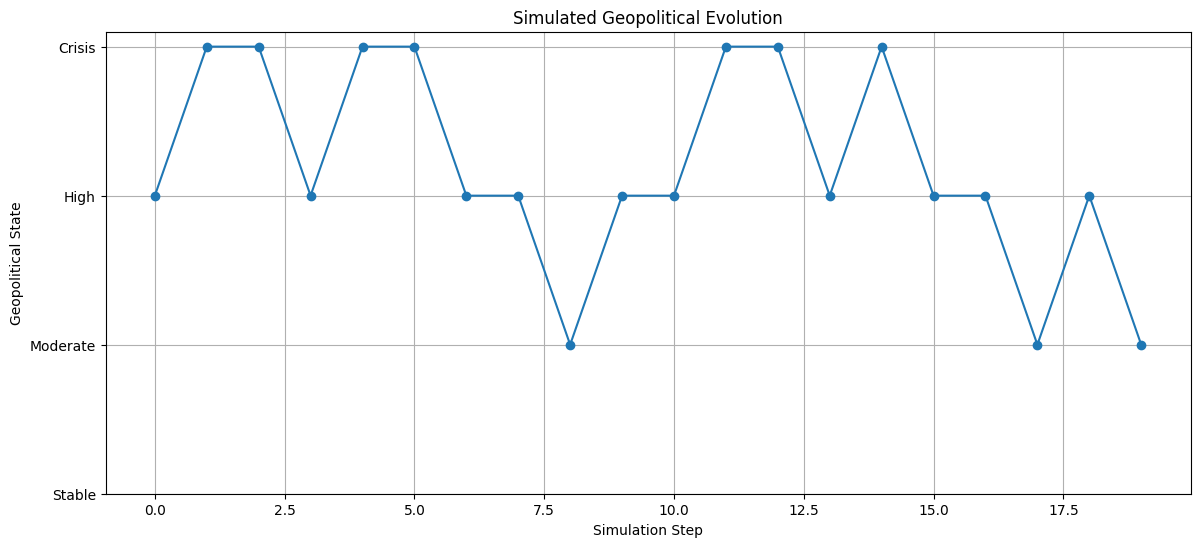

In [28]:
# ============================================================
# VISUALIZE STATE EVOLUTION
# ============================================================

state_numbers = []

for state_name in future_simulation["state"]:

    for number, name in state_mapping.items():

        if name == state_name:
            state_numbers.append(number)

plt.figure(figsize=(14,6))

plt.plot(
    future_simulation["step"],
    state_numbers,
    marker="o"
)

plt.yticks(
    [0,1,2,3],
    ["Stable", "Moderate", "High", "Crisis"]
)

plt.xlabel("Simulation Step")
plt.ylabel("Geopolitical State")

plt.title("Simulated Geopolitical Evolution")

plt.grid(True)

plt.show()

MONTE CARLO SIMULATION ENGINE

In [29]:
# ============================================================
# MONTE CARLO SIMULATION ENGINE
# ============================================================

def monte_carlo_simulation(
    start_state,
    simulations=500,
    steps=20
):

    all_simulations = []

    for sim in range(simulations):

        result = simulate_future(
            start_state=start_state,
            steps=steps
        )

        result["simulation_id"] = sim

        all_simulations.append(result)

    combined_results = pd.concat(
        all_simulations,
        ignore_index=True
    )

    return combined_results

Run Monte Carlo simulation

In [30]:
# ============================================================
# RUN MONTE CARLO
# ============================================================

mc_results = monte_carlo_simulation(
    start_state=2,
    simulations=500,
    steps=20
)

mc_results.head()

,step,state,USA_action,Iran_action,India_action,Oil_Impact_%,SP500_Impact_%,NIFTY50_Impact_%,Gold_Impact_%,VIX_Impact_%,simulation_id
0,0,High Tension,Diplomatic Negotiation,Proxy Escalation,Oil Diversification,3.0,-2.0,-2.5,2.0,4.0,0
1,1,Moderate Tension,Diplomatic Negotiation,Nuclear Expansion,Neutral Diplomacy,1.0,-0.5,-0.8,0.7,1.0,0
2,2,High Tension,Military Pressure,Proxy Escalation,Trade Balancing,3.0,-2.0,-2.5,2.0,4.0,0
3,3,Moderate Tension,Cyber Operations,Oil Route Threat,Trade Balancing,1.0,-0.5,-0.8,0.7,1.0,0
4,4,High Tension,Military Pressure,Proxy Escalation,Energy Security Measures,3.0,-2.0,-2.5,2.0,4.0,0


CRISIS PROBABILITY

In [31]:
# ============================================================
# CRISIS PROBABILITY
# ============================================================

crisis_count = (
    mc_results["state"] == "Crisis"
).sum()

total_states = len(mc_results)

crisis_probability = (
    crisis_count / total_states
) * 100

print(
    f"Crisis Probability: {crisis_probability:.2f}%"
)

Crisis Probability: 38.51%


MOST COMMON STRATEGIC ACTIONS

In [32]:
# ============================================================
# MOST COMMON STRATEGIC ACTIONS
# ============================================================

print("Most Common USA Actions:\n")
print(
    mc_results["USA_action"].value_counts()
)

print("\nMost Common Iran Actions:\n")
print(
    mc_results["Iran_action"].value_counts()
)

print("\nMost Common India Actions:\n")
print(
    mc_results["India_action"].value_counts()
)

Most Common USA Actions:

USA_action
Economic Sanctions        2909
Military Pressure         2748
Naval Deployment          2160
Cyber Operations          1141
Diplomatic Negotiation    1042
Name: count, dtype: int64

Most Common Iran Actions:

Iran_action
Proxy Escalation         3374
Missile Demonstration    2519
Oil Route Threat         1741
Nuclear Expansion        1372
Diplomatic Response       994
Name: count, dtype: int64

Most Common India Actions:

India_action
Oil Diversification         3114
Neutral Diplomacy           2710
Energy Security Measures    1761
Strategic Mediation         1339
Trade Balancing             1076
Name: count, dtype: int64


Market impact distributions

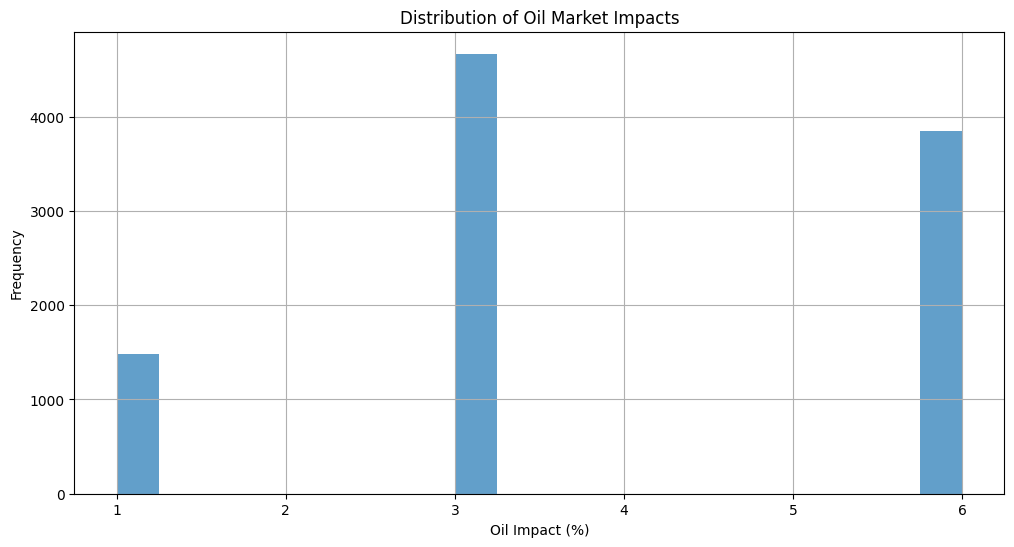

In [33]:
# ============================================================
# MARKET IMPACT DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    mc_results["Oil_Impact_%"],
    bins=20,
    alpha=0.7
)

plt.title("Distribution of Oil Market Impacts")

plt.xlabel("Oil Impact (%)")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

State distribution analysis

In [34]:
# ============================================================
# GEOPOLITICAL STATE DISTRIBUTION
# ============================================================

state_distribution = (
    mc_results["state"]
    .value_counts(normalize=True)
    * 100
)

print(state_distribution)


state
High Tension        46.69
Crisis              38.51
Moderate Tension    14.80
Name: proportion, dtype: float64


Visualize state probabilities

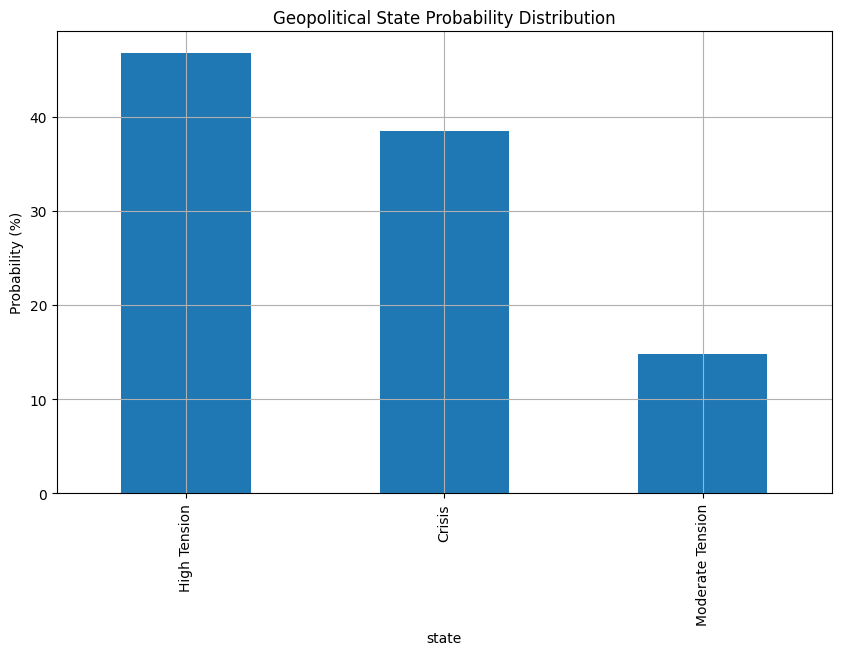

In [35]:
# ============================================================
# VISUALIZE STATE PROBABILITIES
# ============================================================

state_distribution.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Geopolitical State Probability Distribution")

plt.ylabel("Probability (%)")

plt.grid(True)

plt.show()

ADAPTIVE TENSION MEMORY

In [36]:
# ============================================================
# ADAPTIVE TENSION MEMORY
# ============================================================

tension_memory = {

    "recent_crises": 0,
    "recent_high_tension": 0,
    "recent_stable_periods": 0
}

UPDATE TENSION MEMORY

In [37]:
# ============================================================
# UPDATE TENSION MEMORY
# ============================================================

def update_tension_memory(current_state):

    global tension_memory

    if current_state == 3:
        tension_memory["recent_crises"] += 1

    elif current_state == 2:
        tension_memory["recent_high_tension"] += 1

    elif current_state == 0:
        tension_memory["recent_stable_periods"] += 1

ADAPTIVE TRANSITION MODEL

In [38]:
# ============================================================
# ADAPTIVE TRANSITION MODEL
# ============================================================

def adaptive_next_state(current_state):

    probabilities = transition_matrix[current_state].copy()

    crisis_pressure = (
        tension_memory["recent_crises"] * 0.03
    )

    high_tension_pressure = (
        tension_memory["recent_high_tension"] * 0.02
    )

    stability_pressure = (
        tension_memory["recent_stable_periods"] * 0.02
    )

    # Increase crisis probability
    probabilities[3] += crisis_pressure

    # Increase high tension probability
    probabilities[2] += high_tension_pressure

    # Increase stability probability
    probabilities[0] += stability_pressure

    # Normalize probabilities
    probabilities = probabilities / probabilities.sum()

    next_state = np.random.choice(
        [0,1,2,3],
        p=probabilities
    )

    return next_state

ADAPTIVE FUTURE SIMULATION

In [39]:
# ============================================================
# ADAPTIVE FUTURE SIMULATION
# ============================================================

def adaptive_simulation(
    start_state,
    steps=20
):

    global tension_memory

    tension_memory = {

        "recent_crises": 0,
        "recent_high_tension": 0,
        "recent_stable_periods": 0
    }

    results = []

    current_state = start_state

    for step in range(steps):

        update_tension_memory(current_state)

        predicted_actions = predict_actions(current_state)

        impacts = market_impacts[current_state]

        results.append({

            "step": step,

            "state": state_mapping[current_state],

            "USA_action": predicted_actions["USA"],

            "Iran_action": predicted_actions["Iran"],

            "India_action": predicted_actions["India"],

            "Oil_Impact_%": impacts["oil"],

            "SP500_Impact_%": impacts["sp500"],

            "NIFTY50_Impact_%": impacts["nifty"],

            "Gold_Impact_%": impacts["gold"],

            "VIX_Impact_%": impacts["vix"]
        })

        current_state = adaptive_next_state(
            current_state
        )

    return pd.DataFrame(results)

RUN ADAPTIVE SIMULATION

In [40]:
# ============================================================
# RUN ADAPTIVE SIMULATION
# ============================================================

adaptive_results = adaptive_simulation(
    start_state=2,
    steps=30
)

adaptive_results

,step,state,USA_action,Iran_action,India_action,Oil_Impact_%,SP500_Impact_%,NIFTY50_Impact_%,Gold_Impact_%,VIX_Impact_%
0,0,High Tension,Naval Deployment,Proxy Escalation,Energy Security Measures,3.0,-2.0,-2.5,2.0,4.0
1,1,Moderate Tension,Economic Sanctions,Diplomatic Response,Trade Balancing,1.0,-0.5,-0.8,0.7,1.0
2,2,High Tension,Diplomatic Negotiation,Proxy Escalation,Neutral Diplomacy,3.0,-2.0,-2.5,2.0,4.0
3,3,High Tension,Military Pressure,Proxy Escalation,Neutral Diplomacy,3.0,-2.0,-2.5,2.0,4.0
4,4,Moderate Tension,Economic Sanctions,Nuclear Expansion,Strategic Mediation,1.0,-0.5,-0.8,0.7,1.0
5,5,High Tension,Military Pressure,Oil Route Threat,Energy Security Measures,3.0,-2.0,-2.5,2.0,4.0
6,6,Moderate Tension,Economic Sanctions,Diplomatic Response,Strategic Mediation,1.0,-0.5,-0.8,0.7,1.0
7,7,High Tension,Diplomatic Negotiation,Proxy Escalation,Energy Security Measures,3.0,-2.0,-2.5,2.0,4.0
8,8,Moderate Tension,Economic Sanctions,Proxy Escalation,Oil Diversification,1.0,-0.5,-0.8,0.7,1.0
9,9,High Tension,Economic Sanctions,Nuclear Expansion,Oil Diversification,3.0,-2.0,-2.5,2.0,4.0


VISUALIZE ADAPTIVE EVOLUTION

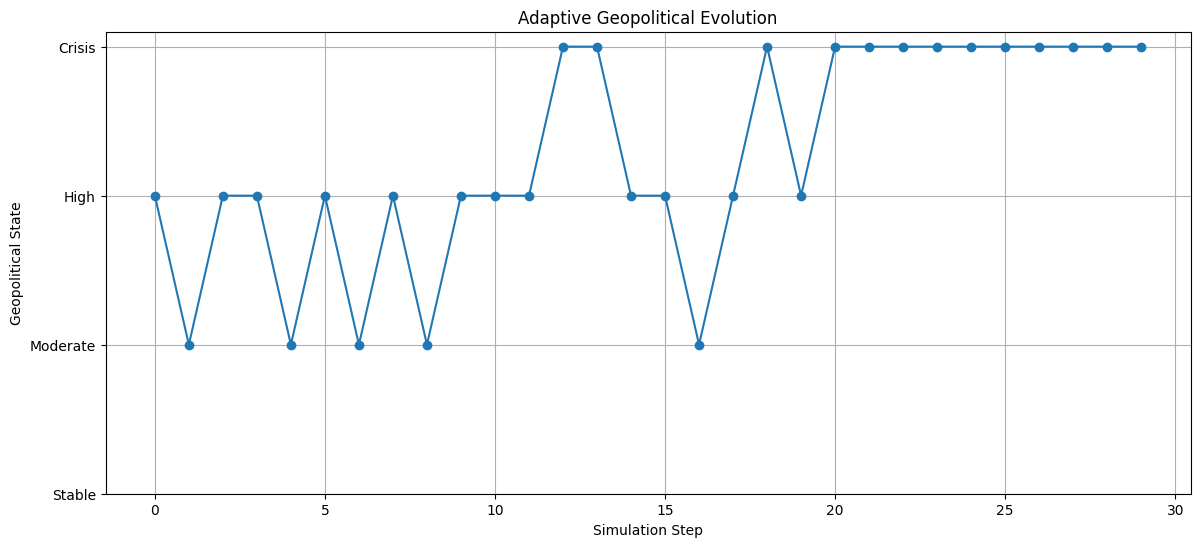

In [41]:
# ============================================================
# VISUALIZE ADAPTIVE EVOLUTION
# ============================================================

adaptive_state_numbers = []

for state_name in adaptive_results["state"]:

    for number, name in state_mapping.items():

        if name == state_name:
            adaptive_state_numbers.append(number)

plt.figure(figsize=(14,6))

plt.plot(
    adaptive_results["step"],
    adaptive_state_numbers,
    marker="o"
)

plt.yticks(
    [0,1,2,3],
    ["Stable", "Moderate", "High", "Crisis"]
)

plt.xlabel("Simulation Step")
plt.ylabel("Geopolitical State")

plt.title("Adaptive Geopolitical Evolution")

plt.grid(True)

plt.show()

BAYESIAN PRIOR PROBABILITIES

In [42]:
# ============================================================
# BAYESIAN PRIOR PROBABILITIES
# ============================================================

bayesian_state_probabilities = {

    0: 0.20,  # Stable
    1: 0.35,  # Moderate
    2: 0.30,  # High Tension
    3: 0.15   # Crisis
}

EVIDENCE LIKELIHOODS

In [43]:
# ============================================================
# EVIDENCE LIKELIHOODS
# ============================================================

evidence_likelihoods = {

    "Missile Strike": {
        0: 0.01,
        1: 0.10,
        2: 0.40,
        3: 0.80
    },

    "Diplomatic Agreement": {
        0: 0.70,
        1: 0.50,
        2: 0.20,
        3: 0.05
    },

    "Oil Route Threat": {
        0: 0.02,
        1: 0.20,
        2: 0.60,
        3: 0.75
    },

    "Economic Sanctions": {
        0: 0.10,
        1: 0.45,
        2: 0.55,
        3: 0.30
    },

    "Naval Deployment": {
        0: 0.05,
        1: 0.30,
        2: 0.55,
        3: 0.60
    }
}

BAYESIAN UPDATE FUNCTION

In [44]:
# ============================================================
# BAYESIAN UPDATE FUNCTION
# ============================================================

def bayesian_update(priors, evidence):

    likelihoods = evidence_likelihoods[evidence]

    posterior = {}

    total_probability = 0

    for state in priors:

        posterior[state] = (
            priors[state]
            * likelihoods[state]
        )

        total_probability += posterior[state]

    # Normalize probabilities
    for state in posterior:

        posterior[state] /= total_probability

    return posterior

In [45]:
# ============================================================
# TEST BAYESIAN UPDATE
# ============================================================

updated_probabilities = bayesian_update(
    bayesian_state_probabilities,
    "Missile Strike"
)

updated_probabilities

{0: 0.007220216606498194,
 1: 0.12635379061371838,
 2: 0.43321299638989164,
 3: 0.43321299638989164}

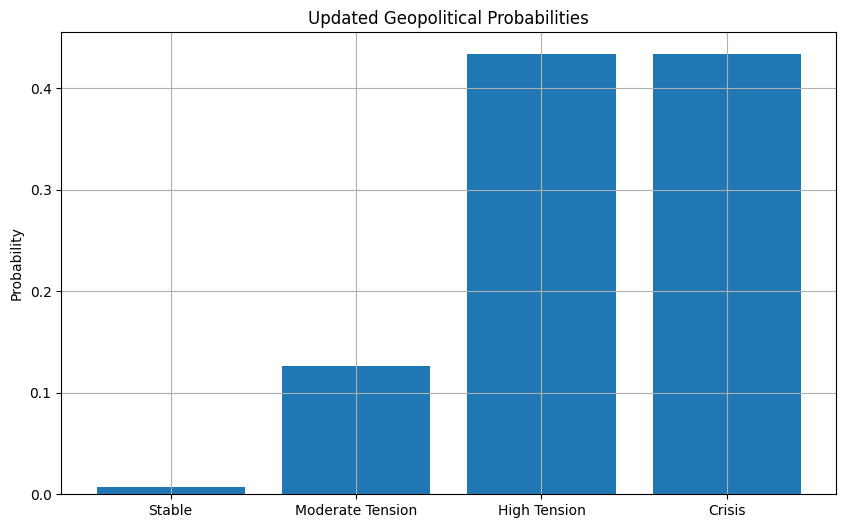

In [46]:
# ============================================================
# VISUALIZE BAYESIAN UPDATE
# ============================================================

states = [
    state_mapping[i]
    for i in updated_probabilities.keys()
]

values = list(
    updated_probabilities.values()
)

plt.figure(figsize=(10,6))

plt.bar(states, values)

plt.title("Updated Geopolitical Probabilities")

plt.ylabel("Probability")

plt.grid(True)

plt.show()

In [47]:
# ============================================================
# REWARD SYSTEM
# ============================================================

reward_system = {

    "USA": {

        "Stable": 5,
        "Moderate Tension": 2,
        "High Tension": -2,
        "Crisis": -5
    },

    "Iran": {

        "Stable": 3,
        "Moderate Tension": 2,
        "High Tension": -1,
        "Crisis": -4
    },

    "India": {

        "Stable": 6,
        "Moderate Tension": 1,
        "High Tension": -3,
        "Crisis": -6
    }
}

In [48]:
# ============================================================
# INITIALIZE Q-VALUES
# ============================================================

q_values = {

    "USA": {},
    "Iran": {},
    "India": {}
}

In [49]:
# ============================================================
# INITIALIZE ACTION VALUES
# ============================================================

for state in [0,1,2,3]:

    state_name = state_mapping[state]

    q_values["USA"][state_name] = {
        action: 0
        for action in usa_actions
    }

    q_values["Iran"][state_name] = {
        action: 0
        for action in iran_actions
    }

    q_values["India"][state_name] = {
        action: 0
        for action in india_actions
    }

In [50]:
# ============================================================
# Q-LEARNING UPDATE
# ============================================================

def update_q_value(
    country,
    state_name,
    action,
    reward,
    learning_rate=0.1
):

    current_q = q_values[country][state_name][action]

    new_q = current_q + (
        learning_rate
        * (reward - current_q)
    )

    q_values[country][state_name][action] = new_q

In [51]:
# ============================================================
# STRATEGIC LEARNING SIMULATION
# ============================================================

def reinforcement_learning_simulation(
    episodes=500
):

    for episode in range(episodes):

        current_state = np.random.choice([0,1,2,3])

        state_name = state_mapping[current_state]

        predictions = predict_actions(current_state)

        usa_action = predictions["USA"]
        iran_action = predictions["Iran"]
        india_action = predictions["India"]

        usa_reward = reward_system["USA"][state_name]
        iran_reward = reward_system["Iran"][state_name]
        india_reward = reward_system["India"][state_name]

        update_q_value(
            "USA",
            state_name,
            usa_action,
            usa_reward
        )

        update_q_value(
            "Iran",
            state_name,
            iran_action,
            iran_reward
        )

        update_q_value(
            "India",
            state_name,
            india_action,
            india_reward
        )

In [52]:
# ============================================================
# TRAIN RL AGENTS
# ============================================================

reinforcement_learning_simulation(
    episodes=1000
)

In [53]:
# ============================================================
# VIEW LEARNED STRATEGIES
# ============================================================

q_values

{'USA': {'Stable': {'Diplomatic Negotiation': 4.999988229398265,
   'Economic Sanctions': 4.9830930404323865,
   'Military Pressure': 2.04755,
   'Naval Deployment': 4.507614548908195,
   'Cyber Operations': 4.94013742408719},
  'Moderate Tension': {'Diplomatic Negotiation': 1.9991778033665886,
   'Economic Sanctions': 1.9990864481850985,
   'Military Pressure': 1.9872746291177281,
   'Naval Deployment': 1.82274123760695,
   'Cyber Operations': 1.840467113846255},
  'High Tension': {'Diplomatic Negotiation': -1.895330473394528,
   'Economic Sanctions': -1.9992600230299298,
   'Military Pressure': -1.9978777667760073,
   'Naval Deployment': -1.9980899900984066,
   'Cyber Operations': -1.803045819563278},
  'Crisis': {'Diplomatic Negotiation': -3.9705443395267546,
   'Economic Sanctions': -4.974231123963399,
   'Military Pressure': -4.999477521618341,
   'Naval Deployment': -4.988907343827689,
   'Cyber Operations': -4.960724163943605}},
 'Iran': {'Stable': {'Diplomatic Response': 2.9999

In [54]:
# ============================================================
# INSTALL NLP PACKAGE
# ============================================================

!pip install vaderSentiment --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.0 MB/s eta 0:00:00


In [55]:
# ============================================================
# IMPORT SENTIMENT ANALYZER
# ============================================================

from vaderSentiment.vaderSentiment import (
    SentimentIntensityAnalyzer
)

analyzer = SentimentIntensityAnalyzer()

In [56]:
# ============================================================
# SAMPLE GEOPOLITICAL HEADLINES
# ============================================================

headlines = [

    "Iran threatens disruption of key oil shipping routes",

    "USA announces additional sanctions on Iran",

    "India urges diplomatic de-escalation in Middle East",

    "Missile strikes increase tensions in the Gulf region",

    "Diplomatic talks resume between Iran and Western powers"
]

In [57]:
# ============================================================
# HEADLINE SENTIMENT ANALYSIS
# ============================================================

headline_sentiments = []

for headline in headlines:

    sentiment = analyzer.polarity_scores(
        headline
    )

    headline_sentiments.append({

        "headline": headline,

        "compound_score": sentiment["compound"]
    })

sentiment_df = pd.DataFrame(
    headline_sentiments
)

sentiment_df

,headline,compound_score
0,Iran threatens disruption of key oil shipping ...,-0.6249
1,USA announces additional sanctions on Iran,0.0000
2,India urges diplomatic de-escalation in Middle...,0.0000
3,Missile strikes increase tensions in the Gulf ...,-0.4404
4,Diplomatic talks resume between Iran and Weste...,0.0000


In [58]:
# ============================================================
# SENTIMENT-BASED TENSION SIGNAL
# ============================================================

def sentiment_to_tension(score):

    if score >= 0.4:
        return "Stable"

    elif score >= 0:
        return "Moderate Tension"

    elif score >= -0.4:
        return "High Tension"

    else:
        return "Crisis"

In [59]:
# ============================================================
# APPLY TENSION CLASSIFICATION
# ============================================================

sentiment_df["predicted_state"] = sentiment_df[
    "compound_score"
].apply(sentiment_to_tension)

sentiment_df

,headline,compound_score,predicted_state
0,Iran threatens disruption of key oil shipping ...,-0.6249,Crisis
1,USA announces additional sanctions on Iran,0.0000,Moderate Tension
2,India urges diplomatic de-escalation in Middle...,0.0000,Moderate Tension
3,Missile strikes increase tensions in the Gulf ...,-0.4404,Crisis
4,Diplomatic talks resume between Iran and Weste...,0.0000,Moderate Tension


In [60]:
# ============================================================
# NEWS-DRIVEN STATE UPDATE
# ============================================================

def update_probabilities_from_news(
    state_probabilities,
    predicted_state
):

    updated = state_probabilities.copy()

    if predicted_state == "Crisis":
        updated[3] += 0.15

    elif predicted_state == "High Tension":
        updated[2] += 0.10

    elif predicted_state == "Stable":
        updated[0] += 0.10

    total = sum(updated.values())

    for state in updated:
        updated[state] /= total

    return updated

In [61]:
# ============================================================
# TEST NEWS-DRIVEN UPDATE
# ============================================================

current_probs = bayesian_state_probabilities.copy()

headline_state = "Crisis"

updated_probs = update_probabilities_from_news(
    current_probs,
    headline_state
)

updated_probs

{0: 0.1739130434782609,
 1: 0.30434782608695654,
 2: 0.2608695652173913,
 3: 0.2608695652173913}

In [62]:
# ============================================================
# SAMPLE STATE FROM PROBABILITIES
# ============================================================

def sample_state(probabilities):

    states = list(probabilities.keys())

    probs = list(probabilities.values())

    return np.random.choice(
        states,
        p=probs
    )

In [63]:
# ============================================================
# UNIFIED FORECASTING ENGINE
# ============================================================

def unified_forecast_engine(

    current_state,
    headline,
    simulation_steps=15

):

    sentiment = analyzer.polarity_scores(
        headline
    )["compound"]

    predicted_state_name = sentiment_to_tension(
        sentiment
    )

    updated_probabilities = (
        update_probabilities_from_news(
            bayesian_state_probabilities.copy(),
            predicted_state_name
        )
    )

    simulation_results = []

    state = sample_state(
        updated_probabilities
    )

    for step in range(simulation_steps):

        actions = predict_actions(state)

        impacts = market_impacts[state]

        simulation_results.append({

            "step": step,

            "state": state_mapping[state],

            "USA_action": actions["USA"],

            "Iran_action": actions["Iran"],

            "India_action": actions["India"],

            "Oil_Impact_%": impacts["oil"],

            "SP500_Impact_%": impacts["sp500"],

            "NIFTY50_Impact_%": impacts["nifty"],

            "Gold_Impact_%": impacts["gold"],

            "VIX_Impact_%": impacts["vix"]
        })

        state = adaptive_next_state(state)

    return pd.DataFrame(simulation_results)

In [64]:
# ============================================================
# TEST UNIFIED ENGINE
# ============================================================

headline = (
    "Iran threatens major retaliation "
    "after new sanctions by the USA"
)

forecast = unified_forecast_engine(

    current_state=2,
    headline=headline,
    simulation_steps=20
)

forecast

,step,state,USA_action,Iran_action,India_action,Oil_Impact_%,SP500_Impact_%,NIFTY50_Impact_%,Gold_Impact_%,VIX_Impact_%
0,0,High Tension,Naval Deployment,Proxy Escalation,Neutral Diplomacy,3.0,-2.0,-2.5,2.0,4.0
1,1,Crisis,Naval Deployment,Missile Demonstration,Oil Diversification,6.0,-5.0,-6.0,4.0,8.0
2,2,Crisis,Cyber Operations,Diplomatic Response,Energy Security Measures,6.0,-5.0,-6.0,4.0,8.0
3,3,Crisis,Military Pressure,Proxy Escalation,Neutral Diplomacy,6.0,-5.0,-6.0,4.0,8.0
4,4,Crisis,Military Pressure,Oil Route Threat,Trade Balancing,6.0,-5.0,-6.0,4.0,8.0
5,5,High Tension,Cyber Operations,Missile Demonstration,Trade Balancing,3.0,-2.0,-2.5,2.0,4.0
6,6,Crisis,Diplomatic Negotiation,Proxy Escalation,Neutral Diplomacy,6.0,-5.0,-6.0,4.0,8.0
7,7,Crisis,Cyber Operations,Proxy Escalation,Oil Diversification,6.0,-5.0,-6.0,4.0,8.0
8,8,Crisis,Cyber Operations,Proxy Escalation,Energy Security Measures,6.0,-5.0,-6.0,4.0,8.0
9,9,Crisis,Military Pressure,Proxy Escalation,Trade Balancing,6.0,-5.0,-6.0,4.0,8.0


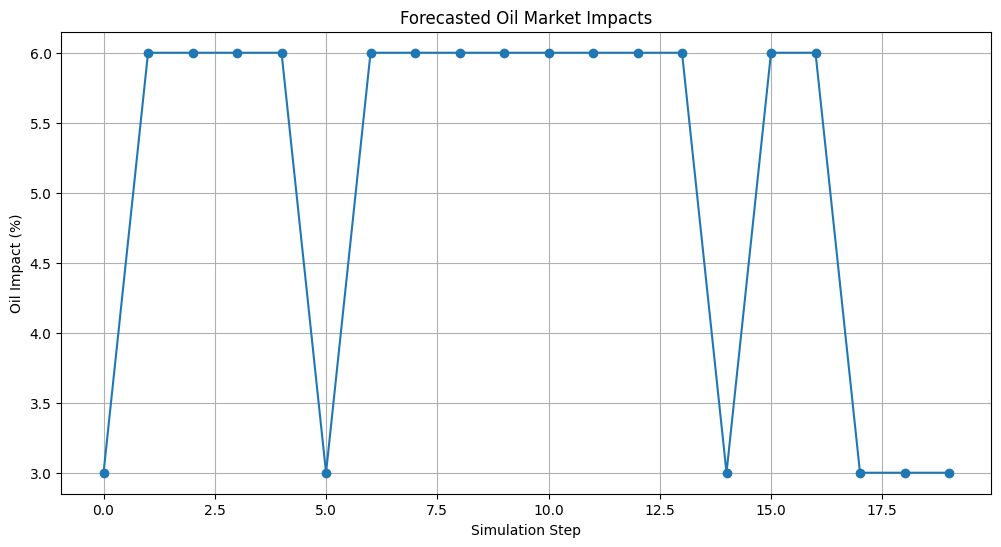

In [65]:
# ============================================================
# VISUALIZE FUTURE OIL IMPACTS
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    forecast["step"],
    forecast["Oil_Impact_%"],
    marker="o"
)

plt.title("Forecasted Oil Market Impacts")

plt.xlabel("Simulation Step")

plt.ylabel("Oil Impact (%)")

plt.grid(True)

plt.show()

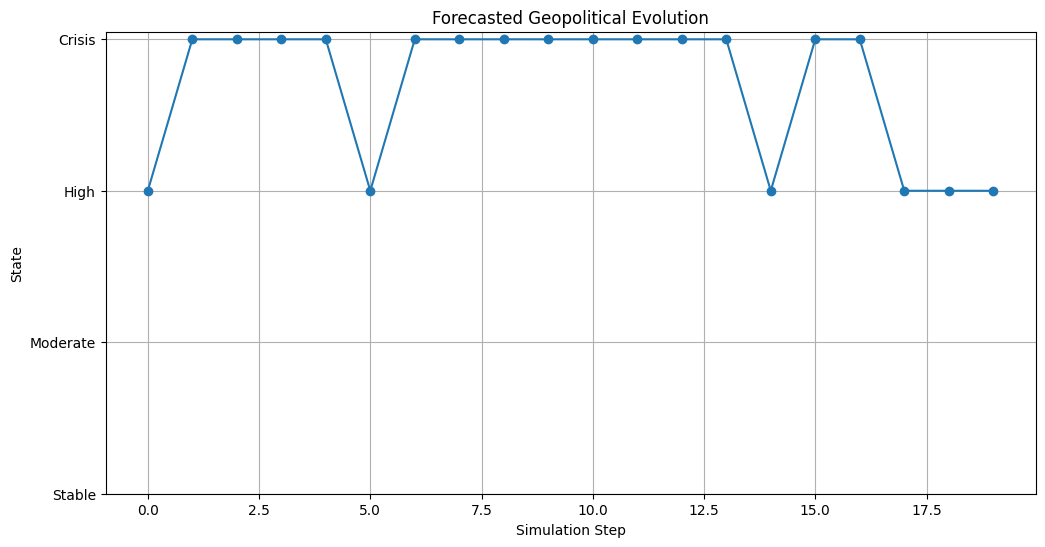

In [66]:
# ============================================================
# VISUALIZE FUTURE STATES
# ============================================================

forecast_states = []

for state_name in forecast["state"]:

    for num, name in state_mapping.items():

        if name == state_name:

            forecast_states.append(num)

plt.figure(figsize=(12,6))

plt.plot(
    forecast["step"],
    forecast_states,
    marker="o"
)

plt.yticks(
    [0,1,2,3],
    ["Stable", "Moderate", "High", "Crisis"]
)

plt.title("Forecasted Geopolitical Evolution")

plt.xlabel("Simulation Step")

plt.ylabel("State")

plt.grid(True)

plt.show()